In [ ]:
# uv pip install numpy polars matplotlib jupyter pyarrow pandas
%matplotlib inline
%config InlineBackend.print_figure_kwargs = {'bbox_inches':None}

import numpy as np
import polars as pl
import matplotlib as mpl
import matplotlib.pyplot as plt
from datetime import datetime
import re
_C = pl.col

plt.ioff()

In [3]:

datasets = pl.DataFrame([
    {
        'name': 'PSI',
        'label': 'PSI / TargetTrack (2017)',
        'date_ended': '2017-10-27',
        'n_datapoints': 946563,
        'host_species': 'mixed',
        'outcome': 'pipeline*',
        'has_dna': 0.12,
        'imbalance': 0.28,
        'quality': 3
    },
    {
        'name': 'SGC_Stockholm',
        'label': 'SGC Stockholm (2013)',
        'date_ended': '2014-01-01', # according to Lovisa, the data was collected in 2005-2013 (Teams chat, 12-May-2026),
        # 'date_ended': '2020-01-31', # the source file is named Expression screening data SGC Sthlm_200131_new.xlsx,
        'host_species': 'E. coli',
        'n_datapoints': 14676,
        'outcome': 'SSE', # small scale expression testing  
        'has_dna': 1.00,
        'imbalance': 0.30,
        'quality': 7
    },
    {
        'name': 'SGC_Toronto',
        'label': 'SGC Toronto (2023)',
        'date_ended': '2023-06-16', # From the file date
        'host_species': 'mixed',
        'n_datapoints': 70585,
        'outcome': 'pipeline**', 
        'has_dna': 0.92,  
        'imbalance': 0.14,
        'quality': 5
    },
    {
        'name': 'DNASU_NESG',
        'label': 'NESG PSI:Biology (2019)',
        'date_ended': '2019-12-10', # Initial commit in SoDoPe paper
        'host_species': 'E. coli',
        'n_datapoints': 12149,
        'outcome': 'SSE', 
        'has_dna': 1.0,  
        'imbalance': 0.67,
        'quality': 6
    },
    {
        'name': 'Secretome',
        'label': 'Human Secretome (2020)',
        'date_ended': '2020-06-01',
        'host_species': 'Mammalian',
        'n_datapoints': 2974,
        'outcome': 'Purification', 
        'has_dna': 1.0,  
        'imbalance': 0.76,
        'quality': 8
    }
]).with_columns(pl.col.date_ended.str.to_date())
datasets.to_pandas()


,name,label,date_ended,n_datapoints,host_species,outcome,has_dna,imbalance,quality
0,PSI,PSI / TargetTrack (2017),2017-10-27,946563,mixed,pipeline*,0.12,0.28,3
1,SGC_Stockholm,SGC Stockholm (2013),2014-01-01,14676,E. coli,SSE,1.00,0.30,7
2,SGC_Toronto,SGC Toronto (2023),2023-06-16,70585,mixed,pipeline**,0.92,0.14,5
3,DNASU_NESG,NESG PSI:Biology (2019),2019-12-10,12149,E. coli,SSE,1.00,0.67,6
4,Secretome,Human Secretome (2020),2020-06-01,2974,Mammalian,Purification,1.00,0.76,8


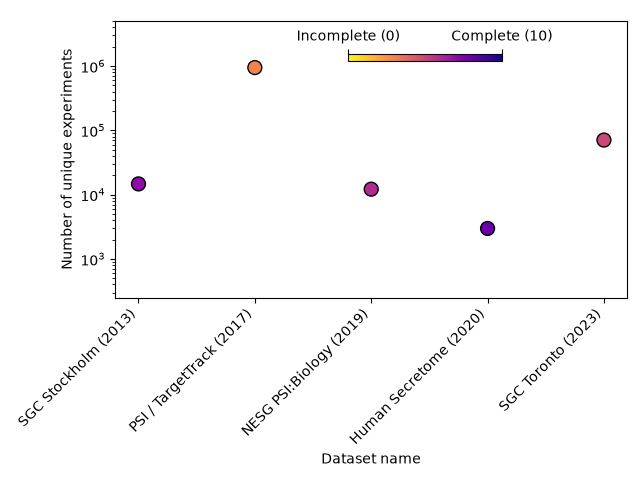

In [13]:
plot_data = datasets.sort('date_ended')
ds_sizes = plot_data.select('n_datapoints').to_numpy().flatten()
ds_quality = plot_data.select('quality').to_numpy().flatten() / 10

plt.close('all')
fig, ax = plt.subplots()
# fig.suptitle("Protein production datasets")

sc = ax.scatter(x=np.arange(plot_data.shape[0]), y=ds_sizes, c=ds_quality, cmap='plasma_r', s=100, ec='black', vmin=0, vmax=1)
ax.set_xticks(np.arange(plot_data.shape[0]))
ax.set_xlabel("Dataset name")

ax.set_yscale('log')
ax.set_ylabel("Number of unique experiments")
ax.set_ylim(bottom=2.5e2, top=5e6)
# tick_labels = plot_data.select('name').to_numpy().flatten()
tick_labels = plot_data['label']
ax.set_xticklabels(tick_labels, rotation=45, ha='right')
def format_cb_tick(x, pos):
    if x == 0:
        return 'Incomplete (0)'
    elif x == 1:
        return 'Complete (10)'
    else:
        return ''
cb = fig.colorbar(sc, ax=ax, 
    ticks=[0, 1], 
    shrink=0.3, 
    format=mpl.ticker.FuncFormatter(format_cb_tick),
    # label='Completeness',
    location='top',
    anchor=(0.65, -1.3)
)
fig.subplots_adjust(top=1.1, bottom=0.38, left=0.18, right=0.98)
fig.savefig("/Users/gene/Documents/nicola_paper_2026/figures/fig1_2.png", dpi=1200)
fig

In [2]:
psi_trial_df = pl.read_parquet('~/data/pp/ai/datasets/17_01/psi/trial.pqt')
psi_trial_df

NameError: name 'pl' is not defined

In [ ]:
psi_trial_seq_df = pl.read_parquet('~/data/pp/ai/datasets/17_01/psi/trial_seq.pqt')
psi_trial_df = pl.read_parquet('~/data/pp/ai/datasets/17_01/psi/trial.pqt')


def pl_expr_seq_is_dna(col_name:str) -> pl.Expr:
    re_dna_full = r'(?i)^[NACGT]+$'
    ret = (pl.col(col_name).str.count_matches(re_dna_full) == 1)
    return ret

def pl_expr_seq_is_protein(col_name:str, max_dna_pct=0.2, sum_dna_pct=0.8) -> pl.Expr:
    """
    Long alanine repeats (AAAAA...) require a high sum_dna_pct threshold
    """
    re_aa_full = r'(?i)^[ABCDEFGHIKLMNPQRSTVWXYZ]+$'
    re_dna = r'(?i)[NACGT]+'
    expr_dna_chunk_lengths = pl.col(col_name).str.extract_all(re_dna).list.eval(pl.element().str.len_bytes()).list
    expr_seq_len = pl.col(col_name).str.len_bytes()
    ret = (pl.col(col_name).str.count_matches(re_aa_full) == 1) & \
        (expr_dna_chunk_lengths.max() < expr_seq_len * max_dna_pct) & \
        (expr_dna_chunk_lengths.sum() < expr_seq_len * sum_dna_pct)
    return ret


def filter_trial_seq_dna(df:pl.LazyFrame, *, lab_filter_expr:pl.Expr|None=None) -> pl.LazyFrame:
    if lab_filter_expr is not None:
        df = df.filter(lab_filter_expr)
    df = (
        df
        .with_columns(is_dna=pl_expr_seq_is_dna('trial_seq'))
        .filter('is_dna')
        .group_by('target_id', 'trial_id')
        .agg(dna_count=_C.is_dna.sum(),trial_seq=_C.trial_seq.first())
        .filter(dna_count=1)
        .select('target_id', 'trial_id', 'trial_seq')
    )
    return df

def filter_trial_seq_protein(df:pl.LazyFrame, *, lab_filter_expr:pl.Expr|None=None) -> pl.LazyFrame:
    if lab_filter_expr is not None:
        df = df.filter(lab_filter_expr)
    df = (
        df
        .with_columns(is_protein=pl_expr_seq_is_protein('trial_seq'))
        .filter('is_protein')
        .group_by('target_id', 'trial_id')
        .agg(protein_count=_C.is_protein.sum(),trial_seq=_C.trial_seq.first())
        .filter(protein_count=1)
        .select('target_id', 'trial_id', 'trial_seq')
    )
    return df


protein_seq = filter_trial_seq_protein(psi_trial_seq_df.lazy())
dna_seq = filter_trial_seq_dna(psi_trial_seq_df.lazy())
psi_trial_df = (
    psi_trial_df.lazy()
    .join(protein_seq.rename({'trial_seq': 'protein_seq'}), on=('target_id', 'trial_id'), how='left', coalesce=True)
    .join(dna_seq.rename({'trial_seq': 'dna_seq'}), on=('target_id', 'trial_id'), how='left', coalesce=True)
)
psi_trial_df = psi_trial_df.collect()
psi_trial_df

target_id,trial_id,date,status,stop_status,stop_remark,protein_seq,dna_seq
str,i64,date,str,str,str,str,str
"""ATCG3D-ATCG3D_1""",1,2008-07-08,"""work stopped""",null,null,"""MGSLQPDAGNASWNGTEAPGGGARATPYSL…",null
"""ATCG3D-ATCG3D_10""",1,2008-07-08,"""work stopped""",null,null,"""MDQFPESVTENFEYDDLAEACYIGDIVVFG…",null
"""ATCG3D-ATCG3D_100""",1,2008-07-16,"""work stopped""",null,null,"""MANASEPGGSGGGEAAALGLKLATLSLLLC…",null
"""ATCG3D-ATCG3D_101""",1,2008-07-16,"""work stopped""",null,null,"""MPFPNCSAPSTVVATAVGVLLGLECGLGLL…",null
"""ATCG3D-ATCG3D_102""",1,2008-07-16,"""work stopped""",null,null,"""MNGVSEGTRGCSDRQPGVLTRDRSCSRKMN…",null
…,…,…,…,…,…,…,…
"""YSG-YPR109w""",1,2003-07-18,"""cloned""",null,null,null,null
"""YSG-YPR116w""",1,2003-07-18,"""expressed""",null,null,null,null
"""YSG-YPR151c""",1,2003-07-18,"""cloned""",null,null,null,null


In [ ]:
psi_trial_df.filter(pl.col.protein_seq.is_not_null()).select(pl.col.dna_seq.is_not_null().mean())

dna_seq
f64
0.121127


In [ ]:
# psi_trial_df.filter(status='work stopped')
psi_trial_df.filter(target_id='NESG-BoR64')

target_id,trial_id,date,status,stop_status,stop_remark,protein_seq,dna_seq
str,i64,date,str,str,str,str,str
"""NESG-BoR64""",1,2010-06-30,"""work stopped""",null,null,"""MLTIDTASRTFHCKTWVTGQTQGKAVIARE…",null
"""NESG-BoR64""",2,2010-06-30,"""work stopped""",null,null,"""MLTIDTASRTFHCKTWVTGQTQGKAVIARE…",null


In [ ]:
trial_history_df = pl.read_parquet("~/data/pp/ai/datasets/17_01/psi/trial_history.pqt")

In [ ]:
trial_history_df.filter(target_id='NESG-BoR64', trial_id=2)

target_id,trial_id,history_id,lab,status,date,prev_history_id
str,i64,i64,str,str,date,i64
"""NESG-BoR64""",2,1,"""NESG""","""selected""",2006-02-28,0
"""NESG-BoR64""",2,2,"""NESG""","""cloned""",2006-06-15,0
"""NESG-BoR64""",2,3,"""NESG""","""expressed""",2006-07-11,0
"""NESG-BoR64""",2,4,"""NESG""","""soluble""",2006-07-11,0
"""NESG-BoR64""",2,50,"""NESG""","""work stopped""",2010-06-30,0


In [ ]:
psi_curated_history_df = pl.read_parquet("~/data/pp/ai/datasets/17_01/psi/psi_curated_history.pqt")

In [ ]:
psi_curated_history_df.filter(target_id='NESG-BoR64')

id,target_id,trial_id,yield_binary,protein_seq,host_species,host_strain,host_protocol_id,vector,vector_protocol_id,last_status,last_status_int
str,str,i64,i8,str,str,str,str,str,str,str,i64
"""PSI_PIPE_293744""","""NESG-BoR64""",2,1,"""MLTIDTASRTFHCKTWVTGQTQGKAVIARE…","""E. coli""","""BL21(DE3)Gold:pMgK""","""NESG-small_scale_expression""",null,null,"""soluble""",5


In [ ]:
sgc_toronto_df = pl.read_parquet('~/data/pp/ai/datasets/17_01/sgc-toronto/sgc_toronto.pqt')
sgc_toronto_df.to_pandas()

,construct_pkey,taxon_genus,taxon_species,ncbi_target_id,target_name,seq_protein_full,vector,host_species,batch_well,cloned_construct_start_pos,...,dna_seq,yield_binary,host_strain,dna_ok,source,experiment_id,test_expression_level,test_expression_level_int,scale,id
0,9989,Homo,sapiens,55501.0,CHST12,MTKARLFRLWLVLGSVFMILLIIVYWDSAGAAHFYLHTSFSRPHTG...,p11_sgc_toronto,E. coli,APC001A10p,41.0,...,ATGGGCAGCAGCCATCATCATCATCATCACAGCAGCGGCAGAGAAA...,False,None,True,SGC_Toronto,6996,None,NaN,large,SGC_T_000000
1,9976,Homo,sapiens,55501.0,CHST12,MTKARLFRLWLVLGSVFMILLIIVYWDSAGAAHFYLHTSFSRPHTG...,p11_sgc_toronto,E. coli,APC001A11p,62.0,...,ATGGGCAGCAGCCATCATCATCATCATCACAGCAGCGGCAGAGAAA...,False,None,True,SGC_Toronto,6996,None,NaN,large,SGC_T_000001
2,9977,Homo,sapiens,55501.0,CHST12,MTKARLFRLWLVLGSVFMILLIIVYWDSAGAAHFYLHTSFSRPHTG...,p11_sgc_toronto,E. coli,APC001A12p,97.0,...,ATGGGCAGCAGCCATCATCATCATCATCACAGCAGCGGCAGAGAAA...,False,None,True,SGC_Toronto,6996,None,NaN,large,SGC_T_000002
3,9966,Homo,sapiens,9486.0,CHST10,MHHQWLLLAACFWVIFMFMVASKFITLTFKDPDVYSAKQEFLFLTT...,p11_sgc_toronto,E. coli,APC001A1p,1.0,...,ATGGGCAGCAGCCATCATCATCATCATCACAGCAGCGGCAGAGAAA...,False,None,True,SGC_Toronto,4616,None,NaN,large,SGC_T_000003
4,9967,Homo,sapiens,9486.0,CHST10,MHHQWLLLAACFWVIFMFMVASKFITLTFKDPDVYSAKQEFLFLTT...,p11_sgc_toronto,E. coli,APC001A2p,30.0,...,ATGGGCAGCAGCCATCATCATCATCATCACAGCAGCGGCAGAGAAA...,False,None,True,SGC_Toronto,4616,None,NaN,large,SGC_T_000004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70580,57447,Plasmodium,falciparum,3320.0,PF07_0029,MSTETFAFNADIRQLMSLIINTFYSNKEIFLRELISNASDALDKIR...,pNIC-CH_sgc_toronto,E. coli,MAC0C1H06,1.0,...,None,False,DH5-Alpha,False,SGC_Toronto,2676,no,0.0,small,SGC_T_070580
70581,57455,Plasmodium,falciparum,0.0,PF14_0346,MEEDDNLKKGNERNKKKAIFSNDDFTGEDSLMEDHLELREKLSEDI...,pNIC-CH_sgc_toronto,E. coli,MAC0C1H07,520.0,...,None,False,None,False,SGC_Toronto,725,no,0.0,small,SGC_T_070581
70582,57463,Plasmodium,falciparum,0.0,PFF0520w,MGNHLSVNKLKRKKKKKSFLNIYGKNTNENTSKQSNDYKYDINTSC...,pNIC-CH_sgc_toronto,E. coli,MAC0C1H08,338.0,...,None,True,None,False,SGC_Toronto,957,high,3.0,small,SGC_T_070582
70583,57471,Plasmodium,falciparum,0.0,PFC0420w,MNDLIIKNNKKGSCDVIIKYKCKKSDENIKRRKSSHKYIKNKSVVL...,pNIC-CH_sgc_toronto,E. coli,MAC0C1H09,92.0,...,None,False,None,False,SGC_Toronto,860,no,0.0,small,SGC_T_070583


In [ ]:
sgc_stockholm_df = pl.read_parquet('~/data/pp/ai/datasets/17_01/sgc-stockholm/sgc_stockholm.pqt')
sgc_stockholm_df.shape

(14991, 16)

In [ ]:
sgc_stockholm_df

construct_id,dna_seq,expression_id,insoluble,soluble,yield_cat,comments,record_creator,protein_seq,host_species,host_strain,vector,id,source,yield_binary,experiment_id
str,str,str,f64,f64,i64,str,str,str,str,str,str,str,str,i32,i64
"""ARR3A-c007""","""ATGCACCATCATCATCATCATTCTTCTGGT…","""ARR3A-e015""",3.0,0.0,2,null,"""FLORAL""","""MHHHHHHSSGVDLGTENLYFQSMKVFKKTS…","""E. coli""","""BL21(DE3) R3 pRARE2""","""pNIC28-Bsa4""","""SGC_S_000000""","""SGC_Stockholm""",1,55
"""ARR3A-c008""","""ATGCACCATCATCATCATCATTCTTCTGGT…","""ARR3A-e016""",3.0,0.0,2,null,"""FLORAL""","""MHHHHHHSSGVDLGTENLYFQSMKVFKKTS…","""E. coli""","""BL21(DE3) R3 pRARE2""","""pNIC28-Bsa4""","""SGC_S_000001""","""SGC_Stockholm""",1,55
"""ARRDC3A-c001""","""ATGCACCATCATCATCATCATTCTTCTGGT…","""ARRDC3A-e006""",0.0,0.0,2,null,"""FLORAL""","""MHHHHHHSSGVDLGTENLYFQSMVLGKVKS…","""E. coli""","""BL21(DE3) R3 pRARE2""","""pNIC28-Bsa4""","""SGC_S_000002""","""SGC_Stockholm""",1,56
"""ARRDC3A-c002""","""ATGCACCATCATCATCATCATTCTTCTGGT…","""ARRDC3A-e007""",0.0,0.0,2,null,"""FLORAL""","""MHHHHHHSSGVDLGTENLYFQSMVLGKVKS…","""E. coli""","""BL21(DE3) R3 pRARE2""","""pNIC28-Bsa4""","""SGC_S_000003""","""SGC_Stockholm""",1,56
"""ARRDC3A-c003""","""ATGCACCATCATCATCATCATTCTTCTGGT…","""ARRDC3A-e008""",0.0,0.0,0,null,"""FLORAL""","""MHHHHHHSSGVDLGTENLYFQSMVLGKVKS…","""E. coli""","""BL21(DE3) R3 pRARE2""","""pNIC28-Bsa4""","""SGC_S_000004""","""SGC_Stockholm""",0,56
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""SOCS7A-c001""","""ATGCACCATCATCATCATCATCACCATCAT…","""SOCS7A-e001""",null,null,0,"""-""","""KOTETE""","""MHHHHHHHHHHDLGTENLYFQSMPQHLQCP…","""E. coli""","""BL21(DE3) R3 pRARE2""","""pNIC28-Bsa4""","""SGC_S_014986""","""SGC_Stockholm""",0,676
"""SRCA-c001""","""ATGCACCATCATCATCATCATCACCATCAT…","""SRCA-e001""",null,null,3,"""-""","""KOTETE""","""MHHHHHHHHHHDLGTENLYFQSMIQAEEWY…","""E. coli""","""BL21(DE3) R3 pRARE2""","""pNIC28-Bsa4""","""SGC_S_014987""","""SGC_Stockholm""",1,684
"""STAP1A-c001""","""ATGCACCATCATCATCATCATCACCATCAT…","""STAP1A-e001""",null,null,2,"""-""","""KOTETE""","""MHHHHHHHHHHDLGTENLYFQSMDYVDVLN…","""E. coli""","""BL21(DE3) R3 pRARE2""","""pNIC28-Bsa4""","""SGC_S_014988""","""SGC_Stockholm""",1,691


In [ ]:
tsuboyama_raw_ngs_dfs = []
for i in range(4):
    df = pl.read_csv(f"~/code/nicola_paper/tsuboyama_nature_2023/Raw_NGS_count_tables/NGS_count_lib{i+1}.csv")
    tsuboyama_raw_ngs_dfs.append(df)
df = pl.concat(tsuboyama_raw_ngs_dfs, how='diagonal')
del tsuboyama_raw_ngs_dfs
df

name,aa_seq,dna_seq,v1_T01,v1_T02,v1_T03,v1_T04,v1_T05,v1_T06,v1_T07,v1_T08,v1_T09,v1_T10,v1_T11,v1_T12,v1_T13,v1_T14,v1_T15,v1_T16,v1_T17,v1_T18,v1_T19,v1_T20,v1_T21,v1_T22,v1_T23,v1_T24,v1_C01,v1_C02,v1_C03,v1_C04,v1_C05,v1_C06,v1_C07,v1_C08,v1_C09,v1_C10,…,v4_T12,v4_T13,v4_T14,v4_T15,v4_T16,v4_T17,v4_T18,v4_T19,v4_T20,v4_T21,v4_T22,v4_T23,v4_T24,v4_C01,v4_C02,v4_C03,v4_C04,v4_C05,v4_C06,v4_C07,v4_C08,v4_C09,v4_C10,v4_C11,v4_C12,v4_C13,v4_C14,v4_C15,v4_C16,v4_C17,v4_C18,v4_C19,v4_C20,v4_C21,v4_C22,v4_C23,v4_C24
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""1A11""","""GSEKMSTAISVLLAQAVFLLLTSQRGSGNG…","""GGTTCTGAAAAAATGTCTACCGCGATCTCT…",10.0,12.0,8.0,13.0,0.0,6.0,4.0,3.0,4.0,3.0,1.0,0.0,7.0,6.0,0.0,2.0,1.0,0.0,0.0,5.0,1.0,0.0,1.0,3.0,105.0,57.0,37.0,52.0,25.0,23.0,29.0,20.0,10.0,20.0,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""1A11_PG_hp""","""GKREATQMLQVLLLSAVLAIFSTSSGSGNG…","""GGTAAACGTGAAGCGACCCAGATGCTGCAG…",48.0,36.0,30.0,16.0,10.0,14.0,9.0,18.0,4.0,6.0,3.0,6.0,23.0,6.0,25.0,17.0,10.0,4.0,6.0,14.0,5.0,2.0,11.0,2.0,87.0,84.0,42.0,49.0,18.0,26.0,49.0,50.0,21.0,18.0,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""1AIE""","""EYFTLQIRGRERFEMFRELNEALELKDAQA…","""GAATACTTCACCCTGCAGATCCGTGGTCGT…",21.0,24.0,17.0,1.0,10.0,1.0,2.0,1.0,2.0,1.0,2.0,1.0,20.0,4.0,0.0,3.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,182.0,55.0,23.0,16.0,7.0,19.0,15.0,24.0,3.0,12.0,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""1AIE_PG_hp""","""QMYEAEFEGQRRIEFFKRANRLLTLEELDA…","""CAGATGTACGAAGCGGAGTTCGAAGGCCAG…",18.0,27.0,12.0,13.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,2.0,21.0,8.0,3.0,4.0,0.0,0.0,3.0,5.0,0.0,0.0,0.0,0.0,163.0,53.0,16.0,9.0,13.0,8.0,9.0,15.0,2.0,6.0,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""1AMB""","""DAEFRHDSGYEVHHQKLVFFAEDVGSNKGN…","""GACGCTGAATTCCGTCACGACTCTGGTTAC…",172.0,201.0,94.0,96.0,78.0,67.0,75.0,36.0,6.0,9.0,1.0,2.0,176.0,152.0,146.0,125.0,88.0,95.0,51.0,16.0,4.0,6.0,9.0,4.0,279.0,290.0,181.0,185.0,116.0,88.0,36.0,31.0,10.0,33.0,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Lib4_dummy_579151""","""-""","""-""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,7.0,261.0,191.0,189.0,143.0,64.0,15.0,6.0,7.0,5.0,8.0,4.0,7.0,263.0,176.0,90.0,22.0,7.0,7.0,6.0,6.0,8.0,4.0,9.0,4.0,241.0,113.0,66.0,18.0,11.0,8.0,8.0,16.0,9.0,20.0,12.0,11.0
"""Lib4_dummy_579152""","""-""","""-""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,8.0,124.0,95.0,105.0,86.0,53.0,39.0,22.0,11.0,5.0,16.0,7.0,4.0,94.0,109.0,75.0,89.0,44.0,15.0,13.0,11.0,1.0,6.0,7.0,4.0,84.0,84.0,87.0,68.0,34.0,17.0,33.0,20.0,13.0,20.0,9.0,12.0
"""Lib4_dummy_579153""","""-""","""-""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null

In [ ]:
re_col_name = re.compile(r'v\d_[CT]\d{2}')
re_col_name_trypsin = re.compile(r'v\d_T\d{2}')
count_cols = [c for c in df.columns if re_col_name.match(c)]
trypsin_cols = [c for c in df.columns if re_col_name_trypsin.match(c)]


In [ ]:
trypsin_cols

['v1_T01',
 'v1_T02',
 'v1_T03',
 'v1_T04',
 'v1_T05',
 'v1_T06',
 'v1_T07',
 'v1_T08',
 'v1_T09',
 'v1_T10',
 'v1_T11',
 'v1_T12',
 'v1_T13',
 'v1_T14',
 'v1_T15',
 'v1_T16',
 'v1_T17',
 'v1_T18',
 'v1_T19',
 'v1_T20',
 'v1_T21',
 'v1_T22',
 'v1_T23',
 'v1_T24',
 'v2_T01',
 'v2_T02',
 'v2_T03',
 'v2_T04',
 'v2_T05',
 'v2_T06',
 'v2_T07',
 'v2_T08',
 'v2_T09',
 'v2_T10',
 'v2_T11',
 'v2_T12',
 'v2_T13',
 'v2_T14',
 'v2_T15',
 'v2_T16',
 'v2_T17',
 'v2_T18',
 'v2_T19',
 'v2_T20',
 'v2_T21',
 'v2_T22',
 'v2_T23',
 'v2_T24',
 'v3_T01',
 'v3_T02',
 'v3_T03',
 'v3_T04',
 'v3_T05',
 'v3_T06',
 'v3_T07',
 'v3_T08',
 'v3_T09',
 'v3_T10',
 'v3_T11',
 'v3_T12',
 'v3_T13',
 'v3_T14',
 'v3_T15',
 'v3_T16',
 'v3_T17',
 'v3_T18',
 'v3_T19',
 'v3_T20',
 'v3_T21',
 'v3_T22',
 'v3_T23',
 'v3_T24',
 'v4_T01',
 'v4_T02',
 'v4_T03',
 'v4_T04',
 'v4_T05',
 'v4_T06',
 'v4_T07',
 'v4_T08',
 'v4_T09',
 'v4_T10',
 'v4_T11',
 'v4_T12',
 'v4_T13',
 'v4_T14',
 'v4_T15',
 'v4_T16',
 'v4_T17',
 'v4_T18',
 'v4_T19',

In [ ]:
df.filter(
    pl.col.aa_seq != '-',
    pl.col.dna_seq != '-',
    ~pl.col.name.str.to_lowercase().str.contains('dummy') ,
    # pl.any_horizontal(pl.col(count_cols) == 0)
)

name,aa_seq,dna_seq,v1_T01,v1_T02,v1_T03,v1_T04,v1_T05,v1_T06,v1_T07,v1_T08,v1_T09,v1_T10,v1_T11,v1_T12,v1_T13,v1_T14,v1_T15,v1_T16,v1_T17,v1_T18,v1_T19,v1_T20,v1_T21,v1_T22,v1_T23,v1_T24,v1_C01,v1_C02,v1_C03,v1_C04,v1_C05,v1_C06,v1_C07,v1_C08,v1_C09,v1_C10,…,v4_T12,v4_T13,v4_T14,v4_T15,v4_T16,v4_T17,v4_T18,v4_T19,v4_T20,v4_T21,v4_T22,v4_T23,v4_T24,v4_C01,v4_C02,v4_C03,v4_C04,v4_C05,v4_C06,v4_C07,v4_C08,v4_C09,v4_C10,v4_C11,v4_C12,v4_C13,v4_C14,v4_C15,v4_C16,v4_C17,v4_C18,v4_C19,v4_C20,v4_C21,v4_C22,v4_C23,v4_C24
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""1A11""","""GSEKMSTAISVLLAQAVFLLLTSQRGSGNG…","""GGTTCTGAAAAAATGTCTACCGCGATCTCT…",10.0,12.0,8.0,13.0,0.0,6.0,4.0,3.0,4.0,3.0,1.0,0.0,7.0,6.0,0.0,2.0,1.0,0.0,0.0,5.0,1.0,0.0,1.0,3.0,105.0,57.0,37.0,52.0,25.0,23.0,29.0,20.0,10.0,20.0,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""1A11_PG_hp""","""GKREATQMLQVLLLSAVLAIFSTSSGSGNG…","""GGTAAACGTGAAGCGACCCAGATGCTGCAG…",48.0,36.0,30.0,16.0,10.0,14.0,9.0,18.0,4.0,6.0,3.0,6.0,23.0,6.0,25.0,17.0,10.0,4.0,6.0,14.0,5.0,2.0,11.0,2.0,87.0,84.0,42.0,49.0,18.0,26.0,49.0,50.0,21.0,18.0,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""1AIE""","""EYFTLQIRGRERFEMFRELNEALELKDAQA…","""GAATACTTCACCCTGCAGATCCGTGGTCGT…",21.0,24.0,17.0,1.0,10.0,1.0,2.0,1.0,2.0,1.0,2.0,1.0,20.0,4.0,0.0,3.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,182.0,55.0,23.0,16.0,7.0,19.0,15.0,24.0,3.0,12.0,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""1AIE_PG_hp""","""QMYEAEFEGQRRIEFFKRANRLLTLEELDA…","""CAGATGTACGAAGCGGAGTTCGAAGGCCAG…",18.0,27.0,12.0,13.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,2.0,21.0,8.0,3.0,4.0,0.0,0.0,3.0,5.0,0.0,0.0,0.0,0.0,163.0,53.0,16.0,9.0,13.0,8.0,9.0,15.0,2.0,6.0,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""1AMB""","""DAEFRHDSGYEVHHQKLVFFAEDVGSNKGN…","""GACGCTGAATTCCGTCACGACTCTGGTTAC…",172.0,201.0,94.0,96.0,78.0,67.0,75.0,36.0,6.0,9.0,1.0,2.0,176.0,152.0,146.0,125.0,88.0,95.0,51.0,16.0,4.0,6.0,9.0,4.0,279.0,290.0,181.0,185.0,116.0,88.0,36.0,31.0,10.0,33.0,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""5GHB.pdb_I68C""","""HINLKVAGQDGSVVQFKIKRHTPLSKLMKA…","""TCCGCGGGTGGTCACATCAACCTGAAAGTT…",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,14.0,129.0,95.0,72.0,78.0,34.0,22.0,12.0,11.0,5.0,13.0,5.0,9.0,130.0,53.0,25.0,25.0,14.0,8.0,6.0,13.0,9.0,10.0,13.0,35.0,89.0,50.0,25.0,13.0,7.0,12.0,8.0,8.0,8.0,13.0,4.0,15.0
"""5GHB.pdb_D69C""","""HINLKVAGQDGSVVQFKIKRHTPLSKLMKA…","""TCTGCTGGCGGTCACATCAACCTGAAAGTT…",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,…,159.0,311.0,269.0,245.0,206.0,172.0,166.0,238.0,328.0,217.0,292.0,122.0,93.0,304.0,351.0,199.0,246.0,198.0,218.0,184.0,266.0,96.0,57.0,30.0,24.0,240.0,256.0,190.0,212.0,226.0,189.0,353.0,2

In [ ]:
df.filter(
    pl.col.aa_seq != '-',
    pl.col.dna_seq != '-',
    ~pl.col.name.str.to_lowercase().str.contains('dummy') ,
).select(
    aa_count=pl.col.aa_seq.n_unique(),
    dna_count=pl.col.dna_seq.n_unique(),
    translate_ok=(rp3.util.pl_expr_seq_translate(pl.col.dna_seq) == pl.col.aa_seq).all()
)

aa_count,dna_count,translate_ok
u32,u32,bool
1824523,1977574,false


In [ ]:
df.filter(
    pl.col.name.str.contains(r'(?i)1a'),
    # pl.any_horizontal(pl.col(trypsin_cols).is_not_null())
).to_pandas()

,name,aa_seq,dna_seq,v1_T01,v1_T02,v1_T03,v1_T04,v1_T05,v1_T06,v1_T07,...,v4_C15,v4_C16,v4_C17,v4_C18,v4_C19,v4_C20,v4_C21,v4_C22,v4_C23,v4_C24
0,1A11,GSEKMSTAISVLLAQAVFLLLTSQRGSGNGSGGNGSGGNGSGNGSG...,GGTTCTGAAAAAATGTCTACCGCGATCTCTGTTCTGCTGGCGCAGG...,10.0,12.0,8.0,13.0,0.0,6.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1A11_PG_hp,GKREATQMLQVLLLSAVLAIFSTSSGSGNGSGGNGSGGNGSGNGSG...,GGTAAACGTGAAGCGACCCAGATGCTGCAGGTTCTGCTGCTGTCTG...,48.0,36.0,30.0,16.0,10.0,14.0,9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1AIE,EYFTLQIRGRERFEMFRELNEALELKDAQAGSGNGSGGNGSGGNGS...,GAATACTTCACCCTGCAGATCCGTGGTCGTGAACGCTTCGAAATGT...,21.0,24.0,17.0,1.0,10.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1AIE_PG_hp,QMYEAEFEGQRRIEFFKRANRLLTLEELDAGSGNGSGGNGSGGNGS...,CAGATGTACGAAGCGGAGTTCGAAGGCCAGCGTCGTATCGAATTCT...,18.0,27.0,12.0,13.0,2.0,2.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1AMB,DAEFRHDSGYEVHHQKLVFFAEDVGSNKGNGSGGNGSGGNGSGNGS...,GACGCTGAATTCCGTCACGACTCTGGTTACGAAGTTCACCACCAAA...,172.0,201.0,94.0,96.0,78.0,67.0,75.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51288,1A32.pdb_V59C,SPEVQIAILTEQINNLNEHLRVHKKDHHSRRGLLKMVGKRRRLLAY...,TCTGCTGGCGGCTCTGCGGGCGGTTCTCCAGAAGTTCAAATCGCTA...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,293.0,272.0,188.0,133.0,112.0,43.0,13.0,14.0,11.0,25.0
51289,1A32.pdb_E60C,SPEVQIAILTEQINNLNEHLRVHKKDHHSRRGLLKMVGKRRRLLAY...,TCCGCTGGCGGCTCCGCGGGTGGTTCTCCGGAAGTTCAGATCGCTA...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,93.0,150.0,79.0,43.0,28.0,8.0,3.0,6.0,4.0,12.0
51290,1A32.pdb_K61C,SPEVQIAILTEQINNLNEHLRVHKKDHHSRRGLLKMVGKRRRLLAY...,TCCGCTGGTGGTTCTGCTGGCGGCTCTCCGGAAGTTCAGATCGCTA...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,190.0,151.0,89.0,78.0,32.0,30.0,2.0,13.0,5.0,12.0
51291,1A32.pdb_L62C,SPEVQIAILTEQINNLNEHLRVHKKDHHSRRGLLKMVGKRRRLLAY...,TCCGCTGGTGGCTCTGCTGGCGGCTCTCCGGAAGTTCAGATTGCGA...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,76.0,60.0,34.0,18.0,14.0,10.0,15.0,5.0,5.0,11.0


In [ ]:
df.filter(pl.col.name.str.replace('.pdb', '') == '1A32').select('aa_seq').item()

'SAGGSPEVQIAILTEQINNLNEHLRVHKKDHHSRRGLLKMVGKRRRLLAYLRNKDVARYREIVEKLGSAGGS'

In [ ]:
import RP3Net as rp3

In [ ]:
rp3.util.pl_expr_seq_translate

<function RP3Net.util.polars.pl_expr_seq_translate(col_expr: polars.expr.expr.Expr) -> polars.expr.expr.Expr>